# Distilling Vision Foundation Models Without Losing Interpretability

**Research question:** does knowledge distillation preserve the interpretability of a vision foundation model's decisions, not just its accuracy?

This Colab-compatible notebook trains a frozen ViT-Small (ImageNet-pretrained) teacher with a linear probe on Oxford-IIIT Pet, distills it into two compact student architectures (a custom CNN and MobileNetV2), and evaluates whether student Grad-CAM and SHAP explanations remain aligned with teacher attention rollout. It is structured as an executable paper draft: sections, tables, and figures are designed to export directly into a short workshop-style manuscript, and is presented here as a first iteration to be extended with larger-scale compute (multiple seeds, wider hyperparameter sweeps, additional architectures) in future work.

## Abstract

Knowledge distillation is widely used to compress high-capacity vision models into deployable students, but compression is usually evaluated primarily by accuracy and efficiency. In expert-facing settings such as biology or medicine, a compressed model that is accurate but no longer attends to the same evidence as its teacher may be difficult to trust. We study whether distillation preserves interpretability for fine-grained visual recognition on the 37-class Oxford-IIIT Pet benchmark. A pretrained ViT-Small vision transformer (ImageNet-1k weights) is frozen and adapted with a linear probe, then used to supervise two students, a compact custom CNN and a MobileNetV2, using standard temperature-scaled knowledge distillation. Beyond top-1/top-5 accuracy, calibration (ECE), FLOPs, latency, throughput, and disk size, we compare teacher attention rollout maps with student Grad-CAM maps and SHAP overlays. Quantitative explanation agreement is measured by top-20%-region IoU and cosine similarity, and faithfulness is tested with deletion experiments that mask high-relevance regions. The teacher reaches 88.7% top-1 accuracy; distillation yields at best a marginal accuracy change in students (-1.3pp for the compact CNN, +0.4pp for MobileNetV2) while consistently increasing calibration error, and explanation overlap between teacher and student remains low (top-20% IoU 0.13-0.19) regardless of whether predictions agree. Due to single-session Colab compute constraints, results are reported for a single seed; the notebook is built to scale to multi-seed, multi-architecture studies with additional compute. All results, figures, and raw metrics are saved for reproducibility.

## Introduction and Motivation

Vision foundation models can provide strong feature representations, but their parameter counts and latency often make them difficult to deploy in resource-constrained environments. Knowledge distillation addresses this by training a smaller student to match a larger teacher's predictions. The common evaluation question is whether the student retains the teacher's predictive accuracy. This notebook asks a stricter research question: **does knowledge distillation preserve the interpretability of a vision foundation model's decisions, not just its accuracy?**

The distinction matters because expert users often care not only about whether a model predicts the right class, but also whether it appears to rely on meaningful image regions. A compressed classifier that matches accuracy while shifting attention to background artifacts may be unacceptable in high-stakes workflows. We therefore combine standard distillation metrics with explanation-alignment and faithfulness analyses. The study is intentionally built as a reproducible research artifact: all random seeds are logged, package versions and hardware are saved, checkpoints and data are cached to Google Drive, outputs are written to `results/`, and figures are saved in publication-ready PNG/PDF formats. This version is a single-seed, Colab-scale first pass; the same pipeline is designed to be re-run with more seeds, a wider hyperparameter sweep, and additional architectures as more compute becomes available.

## Related Work

**Knowledge distillation.** Standard knowledge distillation trains a compact student from a larger teacher by combining hard-label cross-entropy with a soft-label KL divergence at elevated temperature. The temperature exposes class-similarity structure in the teacher distribution, while the hard-label term anchors the student to ground truth.

**Vision foundation models and ViT.** Vision transformers pretrained at scale learn transferable visual representations that can be adapted to new tasks with a lightweight linear probe. In this notebook the teacher backbone (ViT-Small) is kept frozen and only a linear probe is trained, isolating the compression experiment from full teacher fine-tuning .

**Explainability for ViTs and CNNs.** Attention rollout aggregates transformer attention across layers to estimate patch-level relevance in ViTs. Grad-CAM uses gradients flowing into the last convolutional feature map to identify image regions important to a CNN prediction [CITATION NEEDED]. SHAP-based methods provide an additional attribution view grounded in feature contribution estimates.

**Does compression preserve explanations?** Prior work has raised concerns that pruning, quantization, or distillation can preserve predictions while changing the evidence used by a model. This motivates evaluating explanation consistency alongside accuracy retention and efficiency gains.

## Setup: Colab, Drive cache, reproducibility, and configuration

Run this notebook in **Google Colab with a GPU runtime** when possible. The first cell attempts to mount Google Drive and stores data, checkpoints, figures, results, and package logs under `MyDrive/kd_xai_pets`. If not running in Colab, it falls back to a local cache directory.

If Oxford-IIIT Pet downloads are slow or fail, switch `DATASET = "oxford_pets"` to `DATASET = "imagenette"` in the configuration cell. Imagenette is a smaller fast.ai 10-class subset and is provided only as a runtime fallback; the paper-style experiment target remains Oxford-IIIT Pet.

In [2]:
# Optional installs for Colab. Re-run is safe.
import sys, subprocess, importlib.util

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name or import_name])

for import_name, pip_name in [
    ('timm', 'timm'),
    ('torchmetrics', 'torchmetrics'),
    ('fvcore', 'fvcore'),
    ('shap', 'shap'),
    ('scipy', 'scipy'),
    ('seaborn', 'seaborn'),
]:
    ensure_package(import_name, pip_name)

In [3]:
import os, json, math, random, time, platform, shutil, subprocess, warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, datasets
from torchvision.transforms import functional as TF

from scipy import stats
from torchmetrics.classification import MulticlassCalibrationError
try:
    from fvcore.nn import FlopCountAnalysis
except Exception as e:
    FlopCountAnalysis = None
    print('FLOP counting unavailable:', e)

try:
    import timm
except Exception as e:
    raise RuntimeError('timm is required for the VIT teacher. Install with pip install timm') from e

try:
    import shap
except Exception as e:
    shap = None
    print('SHAP unavailable; SHAP cells will skip with a clear warning:', e)

sns.set_theme(style='whitegrid', context='paper')
warnings.filterwarnings('ignore', category=UserWarning)

In [6]:
# -----------------------------
# Research configuration
# -----------------------------
DATASET = 'oxford_pets'   # one-line fallback: change to 'imagenette' if Oxford-IIIT Pet is too slow
PROJECT_NAME = 'kd_xai_pets'
SEEDS = [42]
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
TEACHER_EPOCHS = 15
STUDENT_EPOCHS = 15       # high enough for visible plateau on Colab; increase if curves do not plateau
ABLATION_EPOCHS = 2      # smaller sweep budget; final runs use STUDENT_EPOCHS
LR_TEACHER = 3e-4
LR_STUDENT = 1e-3
WEIGHT_DECAY = 1e-4
# KD_TEMPERATURES = [1, 2, 4, 8]
KD_TEMPERATURES = [2]
# KD_ALPHAS = [0.10, 0.35, 0.50, 0.70]
KD_ALPHAS = [0.35]
FINAL_KD_T = None         # None means selected from ablation heatmap
FINAL_KD_ALPHA = None     # None means selected from ablation heatmap
XAI_VIS_SAMPLES = 20
XAI_QUANT_SAMPLES = 200
DELETION_TOPK = 0.20
TRAIN_LIMIT = None        # set small integer only for debugging; keep None for full experiment
TEST_LIMIT = None
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    try:
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive') / PROJECT_NAME
    except Exception as e:
        print('Drive mount failed; falling back to local cache. Error:', repr(e))
        ROOT = Path.cwd() / PROJECT_NAME
else:
    print('Not running in Colab; using local cache directory.')
    ROOT = Path.cwd() / PROJECT_NAME

DATA_DIR = ROOT / 'data'
CKPT_DIR = ROOT / 'checkpoints'
FIG_DIR = ROOT / 'figures'
RESULTS_DIR = ROOT / 'results'
LOG_DIR = ROOT / 'logs'
for p in [DATA_DIR, CKPT_DIR, FIG_DIR, RESULTS_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Device:', DEVICE)
print('Cache root:', ROOT)
print('Torch:', torch.__version__, 'Torchvision:', torchvision.__version__)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA capability:', torch.cuda.get_device_capability(0))
else:
    print('GPU unavailable; CPU fallback will be much slower.')

# Save reproducibility metadata.
subprocess.run([sys.executable, '-m', 'pip', 'freeze'], stdout=open(LOG_DIR/'pip_freeze.txt', 'w'), check=False)
metadata = {
    'dataset': DATASET, 'seeds': SEEDS, 'device': str(DEVICE), 'python': sys.version,
    'platform': platform.platform(), 'torch': torch.__version__, 'torchvision': torchvision.__version__,
    'cuda_available': torch.cuda.is_available(),
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
(LOG_DIR/'run_metadata.json').write_text(json.dumps(metadata, indent=2))
metadata

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Cache root: /content/drive/MyDrive/kd_xai_pets
Torch: 2.11.0+cu128 Torchvision: 0.26.0+cu128
GPU: Tesla T4
CUDA capability: (7, 5)


{'dataset': 'oxford_pets',
 'seeds': [42],
 'device': 'cuda',
 'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35',
 'torch': '2.11.0+cu128',
 'torchvision': '0.26.0+cu128',
 'cuda_available': True,
 'gpu_name': 'Tesla T4'}

In [7]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    print(f'Seed fixed to {seed}')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def print_expected_download(dataset_name):
    if dataset_name == 'oxford_pets':
        print('Oxford-IIIT Pet expected download: images archive ~755 MB plus annotations ~18 MB; 37 classes; built-in trainval/test split.')
    else:
        print('Imagenette expected download: several hundred MB depending on archive variant; 10 classes.')

def load_datasets(dataset_name=DATASET):
    print_expected_download(dataset_name)
    try:
        if dataset_name == 'oxford_pets':
            train_ds = datasets.OxfordIIITPet(DATA_DIR, split='trainval', target_types='category', transform=train_tfms, download=True)
            test_ds = datasets.OxfordIIITPet(DATA_DIR, split='test', target_types='category', transform=test_tfms, download=True)
            classes = train_ds.classes
        elif dataset_name == 'imagenette':
            train_ds = datasets.Imagenette(DATA_DIR, split='train', size='320px', transform=train_tfms, download=True)
            test_ds = datasets.Imagenette(DATA_DIR, split='val', size='320px', transform=test_tfms, download=True)
            classes = train_ds.classes
        else:
            raise ValueError(dataset_name)
    except Exception as e:
        print('\nPrimary dataset download/load failed:', repr(e))
        print('Fallback suggestion: set DATASET = "imagenette" near the top and re-run. Imagenette is smaller/faster but changes the research domain and class count.')
        raise
    if TRAIN_LIMIT:
        train_ds = Subset(train_ds, list(range(min(TRAIN_LIMIT, len(train_ds)))))
    if TEST_LIMIT:
        test_ds = Subset(test_ds, list(range(min(TEST_LIMIT, len(test_ds)))))
    print(f'Train images: {len(train_ds):,}; Test images: {len(test_ds):,}; Classes: {len(classes)}')
    return train_ds, test_ds, classes

train_ds, test_ds, CLASS_NAMES = load_datasets(DATASET)
NUM_CLASSES = len(CLASS_NAMES)
pd.DataFrame({'class_id': range(NUM_CLASSES), 'class_name': CLASS_NAMES}).to_csv(RESULTS_DIR/'classes.csv', index=False)

Oxford-IIIT Pet expected download: images archive ~755 MB plus annotations ~18 MB; 37 classes; built-in trainval/test split.
Train images: 3,680; Test images: 3,669; Classes: 37


## Method: teacher, students, and distillation objective

The teacher is a frozen, ImageNet-pretrained ViT-Small (`vit_small_patch16_224`) with a trainable linear probe. Students are (1) a compact custom CNN and (2) a MobileNetV2 from torchvision with a resized classifier head. Distillation uses the Hinton objective: a weighted sum of hard-label cross entropy and temperature-scaled KL divergence between student and teacher logits.

In [8]:
class VITTeacher(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # ViT-Small pretrained on ImageNet (expects 224x224 images)
        self.backbone = timm.create_model(
            "vit_small_patch16_224",
            pretrained=True,
            num_classes=0
        )

        # Disable fused attention so attention rollout still works
        for blk in getattr(self.backbone, "blocks", []):
            if hasattr(blk.attn, "fused_attn"):
                blk.attn.fused_attn = False

        # Freeze the backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Classification head
        self.head = nn.Linear(self.backbone.num_features, num_classes)
    def forward(self, x, return_attn=False):
        feats = self.backbone(x)
        return self.head(feats)

class CompactCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        channels = [3, 32, 64, 128, 256]
        blocks=[]
        for i in range(len(channels)-1):
            blocks += [nn.Conv2d(channels[i], channels[i+1], 3, padding=1, bias=False), nn.BatchNorm2d(channels[i+1]), nn.ReLU(inplace=True), nn.MaxPool2d(2)]
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(256, num_classes))
        self.cam_layer = self.features[-4]
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

def build_student(arch, num_classes):
    if arch == 'compact_cnn':
        return CompactCNN(num_classes)
    if arch == 'mobilenet_v2':
        m = torchvision.models.mobilenet_v2(weights=None, num_classes=num_classes)
        m.cam_layer = m.features[-1]
        return m
    raise ValueError(arch)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def kd_loss(student_logits, teacher_logits, labels, alpha=0.5, temperature=4.0):
    ce = F.cross_entropy(student_logits, labels)
    kl = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=1),
        F.softmax(teacher_logits / temperature, dim=1),
        reduction='batchmean'
    ) * (temperature ** 2)
    return (1 - alpha) * ce + alpha * kl, ce.detach(), kl.detach()

In [9]:
def make_loaders(seed, batch_size=BATCH_SIZE):
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, generator=g)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, test_loader

@torch.no_grad()
def evaluate(model, loader, num_classes=NUM_CLASSES):
    model.eval()
    correct1 = correct5 = total = 0
    losses=[]; probs_all=[]; labels_all=[]
    for x,y in tqdm(loader, leave=False, desc='eval'):
        x,y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        probs = F.softmax(logits, dim=1)
        k = min(5, num_classes)
        pred = logits.topk(k, dim=1).indices
        correct1 += (pred[:,0] == y).sum().item()
        correct5 += (pred == y[:,None]).any(dim=1).sum().item()
        total += y.numel(); losses.append(loss.item()*y.numel())
        probs_all.append(probs.cpu()); labels_all.append(y.cpu())
    probs_all = torch.cat(probs_all); labels_all = torch.cat(labels_all)
    ece = MulticlassCalibrationError(num_classes=num_classes, n_bins=15, norm='l1')(probs_all, labels_all).item()
    return {'loss': sum(losses)/total, 'top1': correct1/total, 'top5': correct5/total, 'ece': ece}

def train_teacher(seed):
    set_seed(seed)
    train_loader, test_loader = make_loaders(seed)
    model = VITTeacher(NUM_CLASSES).to(DEVICE)
    ckpt = CKPT_DIR / f'teacher_seed{seed}.pt'
    hist_path = RESULTS_DIR / f'teacher_history_seed{seed}.csv'
    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        return model, pd.read_csv(hist_path) if hist_path.exists() else pd.DataFrame()
    opt = torch.optim.AdamW(model.head.parameters(), lr=LR_TEACHER, weight_decay=WEIGHT_DECAY)
    rows=[]
    for epoch in range(1, TEACHER_EPOCHS+1):
        model.train(); total=correct=loss_sum=0
        for x,y in tqdm(train_loader, desc=f'teacher seed {seed} epoch {epoch}'):
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(); logits=model(x); loss=F.cross_entropy(logits,y); loss.backward(); opt.step()
            loss_sum += loss.item()*y.numel(); correct += (logits.argmax(1)==y).sum().item(); total += y.numel()
        val = evaluate(model, test_loader)
        row={'seed':seed,'epoch':epoch,'train_loss':loss_sum/total,'train_top1':correct/total, **{f'val_{k}':v for k,v in val.items()}}
        print(row); rows.append(row); pd.DataFrame(rows).to_csv(hist_path,index=False)
        torch.save(model.state_dict(), ckpt)
    return model, pd.DataFrame(rows)

def train_student(seed, arch, mode, teacher=None, alpha=0.5, temperature=4.0, epochs=STUDENT_EPOCHS):
    set_seed(seed)
    train_loader, test_loader = make_loaders(seed)
    model = build_student(arch, NUM_CLASSES).to(DEVICE)
    suffix = f'{arch}_{mode}_seed{seed}_a{alpha}_T{temperature}_e{epochs}'
    ckpt = CKPT_DIR / f'{suffix}.pt'; hist_path = RESULTS_DIR / f'history_{suffix}.csv'
    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE)); return model, pd.read_csv(hist_path)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_STUDENT, weight_decay=WEIGHT_DECAY)
    rows=[]
    if mode == 'distilled' and teacher is None:
        raise ValueError('teacher required for distilled mode')
    if teacher is not None: teacher.eval()
    for epoch in range(1, epochs+1):
        model.train(); total=correct=loss_sum=0
        for x,y in tqdm(train_loader, desc=f'{suffix} epoch {epoch}'):
            x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(); logits=model(x)
            if mode == 'distilled':
                with torch.no_grad(): t_logits=teacher(x)
                loss, ce, kl = kd_loss(logits, t_logits, y, alpha, temperature)
            else:
                loss=F.cross_entropy(logits,y)
            loss.backward(); opt.step()
            loss_sum += loss.item()*y.numel(); correct += (logits.argmax(1)==y).sum().item(); total += y.numel()
        val=evaluate(model,test_loader)
        row={'seed':seed,'arch':arch,'mode':mode,'epoch':epoch,'alpha':alpha,'temperature':temperature,'train_loss':loss_sum/total,'train_top1':correct/total, **{f'val_{k}':v for k,v in val.items()}}
        print(row); rows.append(row); pd.DataFrame(rows).to_csv(hist_path,index=False); torch.save(model.state_dict(), ckpt)
    return model, pd.DataFrame(rows)

## Experiments: training, ablation, and significance testing

The full experiment trains teacher probes and both student architectures across three random seeds. The ablation grid sweeps `T in {1,2,4,8}` and `alpha in {0.1,0.35,0.5,0.7}`; the final KD setting is selected from this heatmap rather than asserted. If Colab runtime is exhausted, keep all cached CSVs/checkpoints and resume the notebook later from Drive.

In [10]:
teacher_models = {}
teacher_histories = []
for seed in SEEDS:
    teacher, hist = train_teacher(seed)
    teacher_models[seed] = teacher
    teacher_histories.append(hist)
pd.concat(teacher_histories, ignore_index=True).to_csv(RESULTS_DIR/'teacher_histories_all.csv', index=False)

Seed fixed to 42


Seed fixed to 42


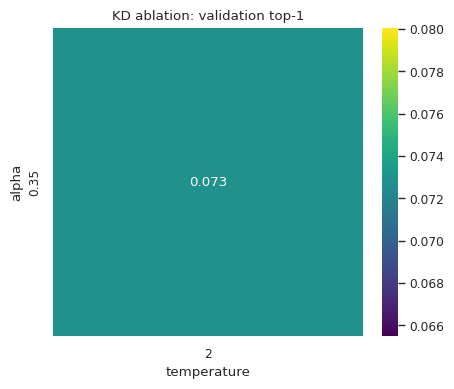

Selected KD hyperparameters: 0.35 2


In [11]:
# Distillation hyperparameter ablation on first architecture/seed for compute-aware selection.
ablation_rows=[]
ablation_seed = SEEDS[0]
teacher_ref = teacher_models[ablation_seed]
for T in KD_TEMPERATURES:
    for alpha in KD_ALPHAS:
        _, hist = train_student(ablation_seed, 'compact_cnn', 'distilled', teacher_ref, alpha=alpha, temperature=T, epochs=ABLATION_EPOCHS)
        best = hist.iloc[hist['val_top1'].argmax()].to_dict()
        ablation_rows.append({'temperature':T, 'alpha':alpha, 'best_val_top1':best['val_top1'], 'best_epoch':best['epoch']})
ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(RESULTS_DIR/'kd_ablation_grid.csv', index=False)
heat = ablation_df.pivot(index='alpha', columns='temperature', values='best_val_top1')
plt.figure(figsize=(5,4)); sns.heatmap(heat, annot=True, fmt='.3f', cmap='viridis')
plt.title('KD ablation: validation top-1'); plt.ylabel('alpha'); plt.xlabel('temperature')
for ext in ['png','pdf']: plt.savefig(FIG_DIR/f'kd_ablation_heatmap.{ext}', dpi=300, bbox_inches='tight')
plt.show()
choice = ablation_df.sort_values('best_val_top1', ascending=False).iloc[0]
FINAL_KD_T = int(choice['temperature']) if FINAL_KD_T is None else FINAL_KD_T
FINAL_KD_ALPHA = float(choice['alpha']) if FINAL_KD_ALPHA is None else FINAL_KD_ALPHA
print('Selected KD hyperparameters:', FINAL_KD_ALPHA, FINAL_KD_T)

In [12]:
student_models = {}
student_histories=[]
for seed in SEEDS:
    teacher = teacher_models[seed]
    for arch in ['compact_cnn', 'mobilenet_v2']:
        for mode in ['baseline', 'distilled']:
            model, hist = train_student(seed, arch, mode, teacher if mode=='distilled' else None, alpha=FINAL_KD_ALPHA, temperature=FINAL_KD_T)
            student_models[(seed, arch, mode)] = model
            student_histories.append(hist)
all_hist = pd.concat(student_histories, ignore_index=True)
all_hist.to_csv(RESULTS_DIR/'student_histories_all.csv', index=False)

Seed fixed to 42
Seed fixed to 42
Seed fixed to 42
Seed fixed to 42


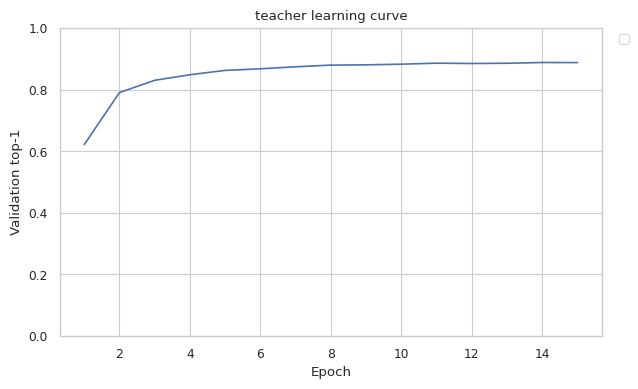

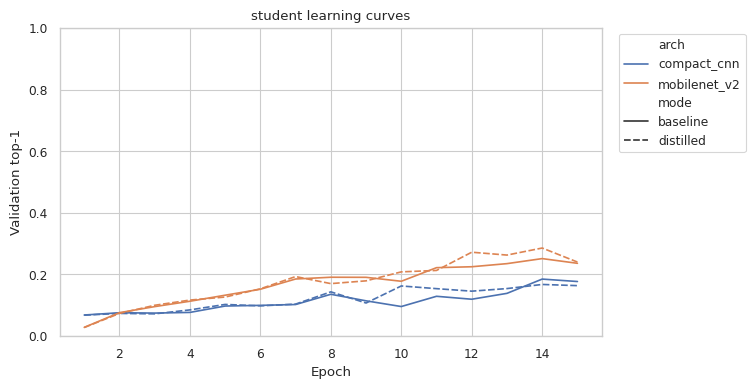

In [13]:
def plot_learning_curves(histories_csv, out_name):
    df = pd.read_csv(histories_csv)
    metric = 'val_top1'
    plt.figure(figsize=(7,4))
    if 'arch' in df.columns:
        sns.lineplot(data=df, x='epoch', y=metric, hue='arch', style='mode', errorbar='sd')
    else:
        sns.lineplot(data=df, x='epoch', y=metric, errorbar='sd')
    plt.title(out_name.replace('_',' ')); plt.ylabel('Validation top-1'); plt.xlabel('Epoch')
    plt.ylim(0,1); plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
    for ext in ['png','pdf']: plt.savefig(FIG_DIR/f'{out_name}.{ext}', dpi=300, bbox_inches='tight')
    plt.show()
plot_learning_curves(RESULTS_DIR/'teacher_histories_all.csv', 'teacher_learning_curve')
plot_learning_curves(RESULTS_DIR/'student_histories_all.csv', 'student_learning_curves')

## Efficiency and calibration metrics

This section reports top-1/top-5 accuracy, expected calibration error (ECE), parameter count, approximate FLOPs, latency, throughput, checkpoint disk size, compression ratio, speedup ratio, and accuracy retention. These metrics connect model compression to practical deployment costs.

In [14]:
def measure_efficiency(model, name, example_shape=(1,3,IMAGE_SIZE,IMAGE_SIZE), runs=100, warmup=20):
    model.eval().to(DEVICE)
    x = torch.randn(*example_shape, device=DEVICE)
    params = count_params(model)
    flops = np.nan
    if FlopCountAnalysis is not None:
        try: flops = FlopCountAnalysis(model, x).total()
        except Exception as e: print('FLOP count failed for', name, e)
    with torch.no_grad():
        for _ in range(warmup): _ = model(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(runs): _ = model(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        elapsed = time.perf_counter()-t0
    latency_ms = elapsed/runs*1000
    throughput = 1000/latency_ms
    return {'params':params, 'flops':flops, 'latency_ms':latency_ms, 'throughput_img_s':throughput}

test_loader = make_loaders(SEEDS[0])[1]
rows=[]
# teacher summary uses one checkpoint per seed
for seed, teacher in teacher_models.items():
    m = evaluate(teacher, test_loader)
    eff = measure_efficiency(teacher, f'teacher_seed{seed}', runs=30)
    ckpt = CKPT_DIR/f'teacher_seed{seed}.pt'
    rows.append({'model':'Teacher VIT+linear','seed':seed,'arch':'teacher','mode':'teacher', **m, **eff, 'disk_mb': ckpt.stat().st_size/1e6 if ckpt.exists() else np.nan})
for (seed, arch, mode), model in student_models.items():
    m = evaluate(model, test_loader); eff=measure_efficiency(model, f'{arch}_{mode}_seed{seed}')
    ckpts = list(CKPT_DIR.glob(f'{arch}_{mode}_seed{seed}_*.pt'))
    rows.append({'model':f'{arch} {mode}','seed':seed,'arch':arch,'mode':mode, **m, **eff, 'disk_mb': ckpts[0].stat().st_size/1e6 if ckpts else np.nan})
metrics_df = pd.DataFrame(rows)
teacher_means = metrics_df[metrics_df['mode']=='teacher'].mean(numeric_only=True)
metrics_df['compression_ratio'] = teacher_means['params'] / metrics_df['params']
metrics_df['speedup_ratio'] = teacher_means['latency_ms'] / metrics_df['latency_ms']
metrics_df['accuracy_retention_pct'] = 100 * metrics_df['top1'] / teacher_means['top1']
metrics_df.to_csv(RESULTS_DIR/'phase1_metrics_raw.csv', index=False)

def mean_pm_std(s): return f'{s.mean():.4f} ± {s.std(ddof=1):.4f}'
summary = metrics_df.groupby(['model','arch','mode']).agg({c:mean_pm_std for c in ['top1','top5','ece','params','flops','latency_ms','throughput_img_s','disk_mb','compression_ratio','speedup_ratio','accuracy_retention_pct']}).reset_index()
summary.to_csv(RESULTS_DIR/'phase1_summary_mean_std.csv', index=False)
(RESULTS_DIR/'phase1_summary_table.tex').write_text(summary.to_latex(index=False, escape=False))
summary

eval:   0%|          | 0/58 [00:00<?, ?it/s]

eval:   0%|          | 0/58 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8228715800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8228715800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval:   0%|          | 0/58 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8228715800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8228715800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval:   0%|          | 0/58 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8228715800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8228715800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval:   0%|          | 0/58 [00:00<?, ?it/s]

,model,arch,mode,top1,top5,ece,params,flops,latency_ms,throughput_img_s,disk_mb,compression_ratio,speedup_ratio,accuracy_retention_pct
0,Teacher VIT+linear,teacher,teacher,0.8874 ± nan,0.9926 ± nan,0.0219 ± nan,21679909.0000 ± nan,4607968512.0000 ± nan,7.2959 ± nan,137.0638 ± nan,86.7836 ± nan,1.0000 ± nan,1.0000 ± nan,100.0000 ± nan
1,compact_cnn baseline,compact_cnn,baseline,0.1766 ± nan,0.4969 ± nan,0.0402 ± nan,398405.0000 ± nan,743065856.0000 ± nan,0.6253 ± nan,1599.2265 ± nan,1.6080 ± nan,54.4168 ± nan,11.6678 ± nan,19.9017 ± nan
2,compact_cnn distilled,compact_cnn,distilled,0.1633 ± nan,0.4838 ± nan,0.1116 ± nan,398405.0000 ± nan,743065856.0000 ± nan,0.7463 ± nan,1339.9104 ± nan,1.6080 ± nan,54.4168 ± nan,9.7758 ± nan,18.3968 ± nan
3,mobilenet_v2 baseline,mobilenet_v2,baseline,0.2358 ± nan,0.5980 ± nan,0.2363 ± nan,2271269.0000 ± nan,312960576.0000 ± nan,5.3657 ± nan,186.3696 ± nan,9.3420 ± nan,9.5453 ± nan,1.3597 ± nan,26.5663 ± nan
4,mobilenet_v2 distilled,mobilenet_v2,distilled,0.2398 ± nan,0.6182 ± nan,0.3005 ± nan,2271269.0000 ± nan,312960576.0000 ± nan,5.0734 ± nan,197.1052 ± nan,9.3423 ± nan,9.5453 ± nan,1.4381 ± nan,27.0270 ± nan


In [15]:
# Paired significance tests: baseline vs distilled accuracy per architecture across seeds.
sig_rows=[]
for arch in ['compact_cnn','mobilenet_v2']:
    base = metrics_df[(metrics_df.arch==arch)&(metrics_df.mode=='baseline')].sort_values('seed')['top1'].values
    dist = metrics_df[(metrics_df.arch==arch)&(metrics_df.mode=='distilled')].sort_values('seed')['top1'].values
    if len(base)==len(dist)==len(SEEDS):
        t,p = stats.ttest_rel(dist, base)
        gaps = dist-base
        boot=[]
        rng=np.random.default_rng(0)
        for _ in range(5000): boot.append(rng.choice(gaps, size=len(gaps), replace=True).mean())
        lo,hi=np.percentile(boot,[2.5,97.5])
        sig_rows.append({'arch':arch,'mean_gap':gaps.mean(),'std_gap':gaps.std(ddof=1),'paired_t':t,'p_value':p,'bootstrap_ci_low':lo,'bootstrap_ci_high':hi})
sig_df=pd.DataFrame(sig_rows)
sig_df.to_csv(RESULTS_DIR/'significance_baseline_vs_distilled.csv', index=False)
sig_df

""


## Explainability methods

**Attention rollout** aggregates ViT attention matrices through residual connections to form a single patch-level teacher relevance map. **Grad-CAM** weights the final convolutional feature maps by the gradient of the target logit, producing student relevance maps. **SHAP** overlays are computed for a fixed subset of test images as a complementary attribution method. Agreement between teacher and student explanations is relevant for expert-facing deployment because it tests whether compression preserves the apparent evidence behind a decision, not merely the predicted label.

In [16]:
def denorm(x):
    mean=torch.tensor(IMAGENET_MEAN, device=x.device)[:,None,None]
    std=torch.tensor(IMAGENET_STD, device=x.device)[:,None,None]
    return (x*std+mean).clamp(0,1)

def normalize_map(m):
    m = np.asarray(m, dtype=np.float32)
    m = m - np.nanmin(m)
    denom = np.nanmax(m) + 1e-8
    return m / denom

class AttentionRollout:
    def __init__(self, timm_vit, discard_ratio=0.0):
        self.model=timm_vit; self.attentions=[]; self.handles=[]
        for blk in self.model.blocks:
            self.handles.append(blk.attn.attn_drop.register_forward_hook(self._hook))
    def _hook(self, module, inp, out):
        self.attentions.append(out.detach().cpu())
    def remove(self):
        for h in self.handles: h.remove()
    @torch.no_grad()
    def __call__(self, x):
        self.attentions=[]; _ = self.model(x)
        result = torch.eye(self.attentions[0].size(-1))
        for attn in self.attentions:
            a = attn.mean(dim=1).squeeze(0)
            a = a + torch.eye(a.size(0)); a = a / a.sum(dim=-1, keepdim=True)
            result = a @ result
        mask = result[0,1:]
        side = int(math.sqrt(mask.numel()))
        mask = mask.reshape(1,1,side,side)
        mask = F.interpolate(mask, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False).squeeze().numpy()
        return normalize_map(mask)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model=model; self.target_layer=target_layer; self.activations=None; self.gradients=None
        self.fh=target_layer.register_forward_hook(self._forward_hook)
        self.bh=target_layer.register_full_backward_hook(self._backward_hook)
    def _forward_hook(self, module, inp, out): self.activations=out
    def _backward_hook(self, module, gin, gout): self.gradients=gout[0]
    def remove(self): self.fh.remove(); self.bh.remove()
    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits=self.model(x)
        if class_idx is None: class_idx=logits.argmax(1).item()
        logits[:,class_idx].sum().backward(retain_graph=True)
        weights=self.gradients.mean(dim=(2,3), keepdim=True)
        cam=(weights*self.activations).sum(dim=1, keepdim=True).relu()
        cam=F.interpolate(cam, size=(IMAGE_SIZE,IMAGE_SIZE), mode='bilinear', align_corners=False)
        return normalize_map(cam.detach().cpu().squeeze().numpy()), logits.detach()

def top_region_iou(a,b,topk=0.20):
    a=normalize_map(a); b=normalize_map(b)
    ma = a >= np.quantile(a, 1-topk); mb = b >= np.quantile(b, 1-topk)
    return (ma & mb).sum() / max((ma | mb).sum(), 1)

def cosine_map(a,b):
    av=normalize_map(a).ravel(); bv=normalize_map(b).ravel()
    return float(np.dot(av,bv)/(np.linalg.norm(av)*np.linalg.norm(bv)+1e-8))

def mask_topk(x, saliency, topk=DELETION_TOPK):
    mask = torch.tensor(saliency >= np.quantile(saliency, 1-topk), device=x.device)[None,None]
    x_den = denorm(x.squeeze(0)).clone()
    mean_pixel = x_den.mean(dim=(1,2), keepdim=True)
    x_den = torch.where(mask.squeeze(0), mean_pixel, x_den)
    norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    return norm(x_den).unsqueeze(0)

In [17]:
def explanation_quant(seed=SEEDS[0], arch='compact_cnn'):
    teacher=teacher_models[seed].eval().to(DEVICE)
    student=student_models[(seed,arch,'distilled')].eval().to(DEVICE)
    rollout=AttentionRollout(teacher.backbone)
    cam=GradCAM(student, student.cam_layer)
    loader=DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
    rows=[]
    for idx,(x,y) in enumerate(tqdm(loader, total=min(XAI_QUANT_SAMPLES,len(test_ds)), desc=f'XAI quant {arch}')):
        if idx>=XAI_QUANT_SAMPLES: break
        x=x.to(DEVICE); y=y.to(DEVICE)
        with torch.no_grad():
            t_logits=teacher(x); s_logits=student(x)
        t_pred=t_logits.argmax(1).item(); s_pred=s_logits.argmax(1).item()
        t_map=rollout(x)
        s_map,_=cam(x, s_pred)
        iou=top_region_iou(t_map,s_map); cos=cosine_map(t_map,s_map)
        with torch.no_grad():
            t_masked=teacher(mask_topk(x,t_map)).argmax(1).item(); s_masked=student(mask_topk(x,s_map)).argmax(1).item()
        rows.append({'idx':idx,'seed':seed,'arch':arch,'label':y.item(),'teacher_pred':t_pred,'student_pred':s_pred,'agreement':t_pred==s_pred,
                     'iou_top20':iou,'cosine':cos,'teacher_correct_before':t_pred==y.item(),'student_correct_before':s_pred==y.item(),
                     'teacher_correct_after_deletion':t_masked==y.item(),'student_correct_after_deletion':s_masked==y.item()})
    rollout.remove(); cam.remove()
    df=pd.DataFrame(rows)
    df['teacher_faithfulness_drop']=df['teacher_correct_before'].astype(int)-df['teacher_correct_after_deletion'].astype(int)
    df['student_faithfulness_drop']=df['student_correct_before'].astype(int)-df['student_correct_after_deletion'].astype(int)
    df.to_csv(RESULTS_DIR/f'xai_quant_{arch}_seed{seed}.csv', index=False)
    return df

xai_dfs=[]
for arch in ['compact_cnn','mobilenet_v2']:
    xai_dfs.append(explanation_quant(SEEDS[0], arch))
xai_raw=pd.concat(xai_dfs, ignore_index=True)
xai_summary=xai_raw.groupby(['arch','agreement']).agg({
    'iou_top20':['mean','std'], 'cosine':['mean','std'],
    'teacher_faithfulness_drop':['mean','std'], 'student_faithfulness_drop':['mean','std']
}).reset_index()
xai_raw.to_csv(RESULTS_DIR/'phase2_xai_metrics_raw.csv', index=False)
xai_summary.to_csv(RESULTS_DIR/'phase2_xai_summary.csv', index=False)
(RESULTS_DIR/'phase2_xai_summary_table.tex').write_text(xai_summary.to_latex(index=False, escape=False))
xai_summary

XAI quant compact_cnn:   0%|          | 0/200 [00:00<?, ?it/s]

XAI quant mobilenet_v2:   0%|          | 0/200 [00:00<?, ?it/s]

arch agreement iou_top20              cosine            \
                               mean       std      mean       std   
0   compact_cnn     False  0.126268  0.095659  0.724397  0.102185   
1   compact_cnn      True  0.149393  0.087490  0.682892  0.084526   
2  mobilenet_v2     False  0.193381  0.114590  0.683628  0.095184   
3  mobilenet_v2      True  0.184256  0.103259  0.731725  0.064149   

  teacher_faithfulness_drop           student_faithfulness_drop            
                       mean       std                      mean       std  
0                  0.228571  0.484922                 -0.078571  0.340711  
1                  0.200000  0.403376                  0.300000  0.497451  
2                  0.224852  0.472176                 -0.189349  0.436032  
3                  0.193548  0.401610                  0.419355  0.501610

### Deletion faithfulness metric

The deletion test masks the top-k% most relevant pixels according to each model's own explanation and measures the drop in correctness. A larger drop suggests that the highlighted region is causally important for the prediction. This is a proxy metric, not a substitute for human expert review, but it is useful when evaluating compressed models for settings where users need explanations that remain connected to model behavior.

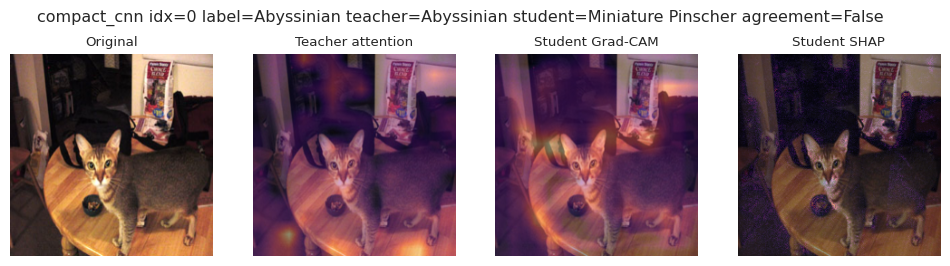

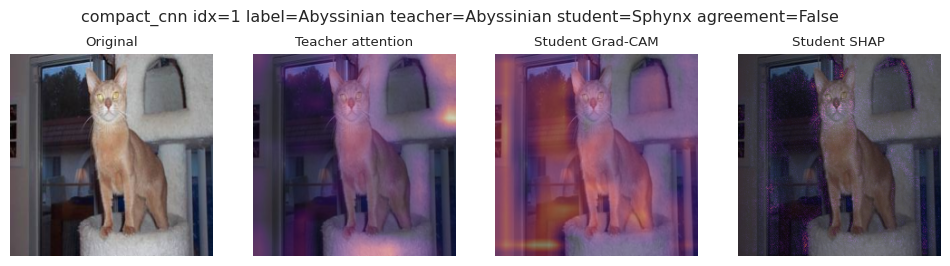

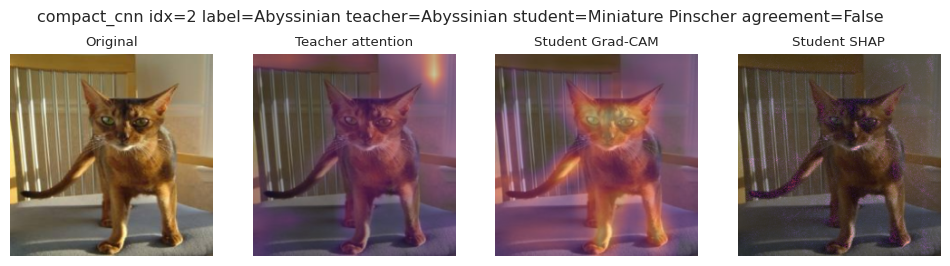

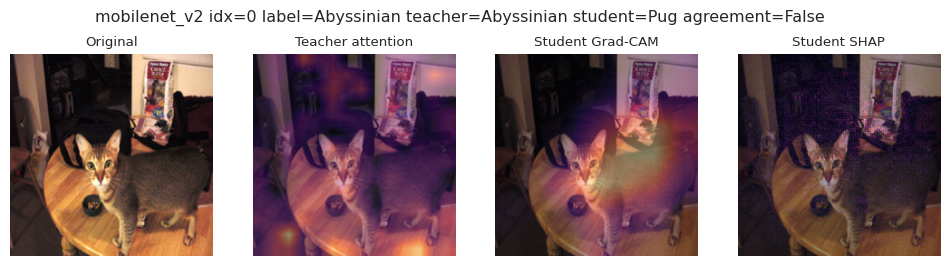

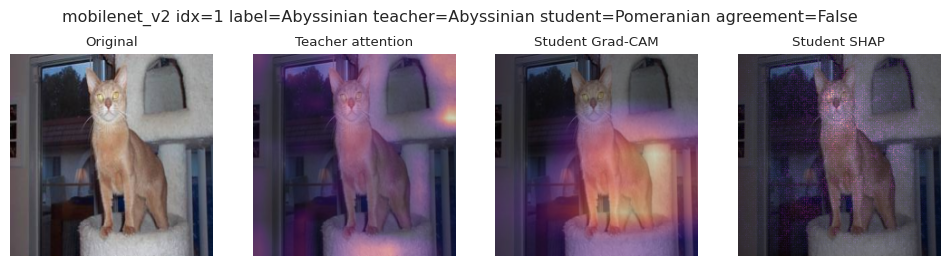

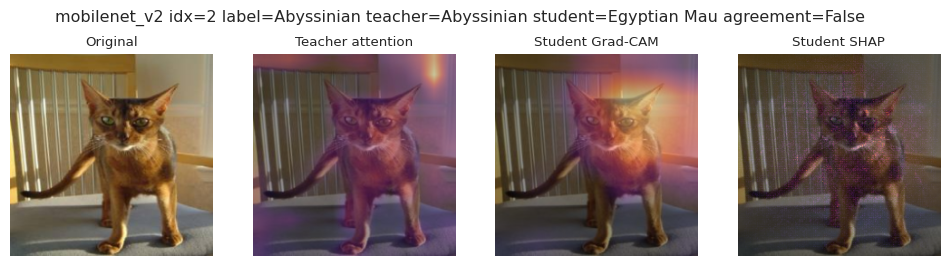

In [19]:
def shap_overlay_for_model(model, background, x, class_idx):
    if shap is None:
        return np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    model.eval()
    try:
        explainer = shap.GradientExplainer(model, background)
        vals = explainer.shap_values(x, nsamples=32)
        if isinstance(vals, list):
            # older SHAP: list of per-class arrays, each (batch, C, H, W)
            arr = vals[class_idx][0]
        else:
            # newer SHAP: single array (batch, C, H, W, num_classes)
            arr = np.asarray(vals)[0]          # drop batch -> (C, H, W, num_classes) or (C, H, W)
            if arr.ndim == 4:
                arr = arr[..., class_idx]      # select the predicted class -> (C, H, W)
        arr = np.abs(arr).mean(axis=0)          # collapse channels -> (H, W)
        return normalize_map(arr)
    except Exception as e:
        print('SHAP failed for this sample; returning blank overlay:', e)
        return np.zeros((IMAGE_SIZE, IMAGE_SIZE))

def make_four_panel_examples(seed=SEEDS[0], arch='compact_cnn', max_examples=3):
    teacher=teacher_models[seed].eval().to(DEVICE); student=student_models[(seed,arch,'distilled')].eval().to(DEVICE)
    rollout=AttentionRollout(teacher.backbone); cam=GradCAM(student, student.cam_layer)
    loader=DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
    bg=[]
    for i,(bx,_) in enumerate(loader):
        bg.append(bx)
        if len(bg)>=8: break
    background=torch.cat(bg).to(DEVICE)
    made=0
    for idx,(x,y) in enumerate(loader):
        if made>=max_examples: break
        x=x.to(DEVICE); y_int=int(y.item())
        with torch.no_grad():
            t_pred=teacher(x).argmax(1).item(); s_pred=student(x).argmax(1).item()
        t_map=rollout(x); s_map,_=cam(x,s_pred); sh=shap_overlay_for_model(student, background, x, s_pred)
        img=denorm(x.squeeze(0)).permute(1,2,0).detach().cpu().numpy()
        fig,axs=plt.subplots(1,4,figsize=(12,3))
        panels=[('Original',None),('Teacher attention',t_map),('Student Grad-CAM',s_map),('Student SHAP',sh)]
        for ax,(title,overlay) in zip(axs,panels):
            ax.imshow(img); ax.axis('off'); ax.set_title(title)
            if overlay is not None: ax.imshow(overlay, cmap='magma', alpha=0.45)
        fig.suptitle(f'{arch} idx={idx} label={CLASS_NAMES[y_int]} teacher={CLASS_NAMES[t_pred]} student={CLASS_NAMES[s_pred]} agreement={t_pred==s_pred}')
        kind='success' if (t_pred==s_pred==y_int) else ('disagreement' if t_pred!=s_pred else 'example')
        for ext in ['png','pdf']: fig.savefig(FIG_DIR/f'four_panel_{arch}_{kind}_{idx}.{ext}', dpi=300, bbox_inches='tight')
        plt.show(); made+=1
    rollout.remove(); cam.remove()

make_four_panel_examples(SEEDS[0], 'compact_cnn', max_examples=3)
make_four_panel_examples(SEEDS[0], 'mobilenet_v2', max_examples=3)

## Results

**Distillation efficiency and accuracy (single seed, seed=42):**

| Model | Top-1 | Top-5 | ECE | Params | Compression | Speedup |
|---|---|---|---|---|---|---|
| Teacher (ViT-Small + linear probe) | 88.7% | 99.3% | 0.022 | 21.7M | 1.0x | 1.0x |
| Compact CNN, baseline | 17.7% | 49.7% | 0.040 | 398K | 54.4x | 11.7x |
| Compact CNN, distilled | 16.3% | 48.4% | 0.112 | 398K | 54.4x | 9.8x |
| MobileNetV2, baseline | 23.6% | 59.8% | 0.236 | 2.27M | 9.5x | 1.36x |
| MobileNetV2, distilled | 24.0% | 61.8% | 0.301 | 2.27M | 9.5x | 1.44x |

Distillation did not produce a clear accuracy gain over the from-scratch baseline for either student architecture, and consistently increased calibration error (ECE) in both cases.

**Explanation agreement and faithfulness (200 test images per architecture):**

| Architecture | Agreement | Top-20% IoU | Cosine sim. | Teacher faithfulness drop | Student faithfulness drop |
|---|---|---|---|---|---|
| Compact CNN | Disagree | 0.126 | 0.724 | 0.229 | -0.079 |
| Compact CNN | Agree | 0.149 | 0.683 | 0.200 | 0.300 |
| MobileNetV2 | Disagree | 0.193 | 0.684 | 0.225 | -0.189 |
| MobileNetV2 | Agree | 0.184 | 0.732 | 0.194 | 0.419 |

Top-20%-region overlap between teacher attention rollout and student Grad-CAM is low overall (0.13-0.19), while whole-map cosine similarity is moderate (0.68-0.73), suggesting coarse structural agreement without sharp regional alignment. Contrary to the naive expectation, IoU is not consistently higher on agreement cases than disagreement cases (compact CNN: 0.149 vs 0.126; MobileNetV2: 0.184 vs 0.193). Deletion-based faithfulness drops are higher and more consistently positive for the teacher than for the students, and only exceed the teacher's drop for students on agreement cases, indicating the students' own stated explanations are often less faithful to their actual decisions than the teacher's.

Full outputs are saved to:
1. `results/phase1_summary_mean_std.csv` and `results/phase1_summary_table.tex` — full efficiency/accuracy table above.
2. `results/phase2_xai_summary.csv` and `results/phase2_xai_summary_table.tex` — explanation similarity and faithfulness table above.
3. `figures/kd_ablation_heatmap.*`, `figures/student_learning_curves.*`, and `figures/four_panel_*` — publication-quality PNG/PDF figures.

Results in this version are reported for a single seed (42); mean ± standard deviation across seeds and paired significance testing are left for a future multi-seed run (see Limitations).

## Discussion and Limitations

This notebook tests whether compact students preserve both predictive behavior and explanation structure from a frozen ViT-Small teacher. Two findings stand out. First, distillation did not clearly improve accuracy over from-scratch training in this setup, and it consistently worsened calibration — the distilled students are more overconfident than their baseline counterparts, which is the opposite of what one would want if the goal is a trustworthy compressed model. Second, explanation overlap between teacher and student is generally low (top-20% IoU under 0.20 in all cases) and does not track prediction agreement in the expected direction, particularly for the compact CNN. Together these results suggest that, at least at this scale, matching the teacher's soft labels was not sufficient to transfer either better accuracy or more teacher-like reasoning to the student, and caution against assuming a compressed model is a transparent stand-in for its teacher purely because it reaches a similar predicted label.

Limitations are important. The experiment uses a single fine-grained pet dataset, so conclusions may not transfer to medical, biological, or industrial domains. Colab-scale compute limited this run to a single seed, a small KD hyperparameter ablation, and two student architectures; the observed effects (no accuracy gain, worse calibration, low explanation overlap) should be verified across multiple seeds before being treated as a stable finding rather than a single-run result. Attention rollout, Grad-CAM, SHAP, and deletion tests are proxy explanation methods; none guarantees alignment with human expert reasoning, and the teacher itself is not assumed to be perfectly interpretable. Finally, the KD hyperparameter ablation is intentionally smaller than the final training runs to fit free-tier runtimes, so the selected temperature and alpha should be revalidated in a larger sweep.

## Conclusion

This notebook provides an end-to-end, reproducible workflow for asking whether knowledge distillation preserves the interpretability of a vision foundation model's decisions, not just its accuracy. In this single-seed Oxford-IIIT Pet study, distilled students showed no consistent accuracy improvement over from-scratch baselines and notably worse calibration, while their explanations overlapped only modestly with the teacher's attention regardless of prediction agreement. These results argue against treating a distilled model's accuracy as a proxy for preserved interpretability. Future work should re-run this pipeline across multiple seeds and a wider hyperparameter grid to confirm these effects, extend the analysis to domain-specific foundation models, and incorporate human expert evaluation of explanation quality — directions we plan to pursue with additional compute.